In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

In [2]:
# Rutas base del proyecto
PROJECT_DIR = Path("..").resolve()

SILVER_DIR = PROJECT_DIR / "outputs" / "m2" / "silver"
GOLD_DIR = PROJECT_DIR / "outputs" / "m2" / "gold"
FIGURES_DIR = PROJECT_DIR / "outputs" / "m2" / "figures"

# Crear carpetas si no existen
GOLD_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Archivo de entrada desde Silver
CLIENTS_FEATURES_PATH = SILVER_DIR / "clients_features.csv"

# Archivos de salida Gold
CLIENTS_CLUSTERED_PATH = GOLD_DIR / "clients_clustered.csv"
CLUSTER_PROFILE_PATH = GOLD_DIR / "cluster_profile.csv"

In [3]:
# leer la tabla silver
clients_features = pd.read_csv(CLIENTS_FEATURES_PATH)
clients_features.head()

,client_id,business_name,store_type,zone,registration_date,first_purchase_date,last_purchase_date,length_days,recency_days,frequency,...,R_log,M_log,L_minmax,R_minmax,R_score,F_minmax,M_minmax,V_minmax,score_lrfmv,score_lrfmv_0_100
0,CLI-0001,Pollería El Centro,restaurante,Chilca,2021-10-14,2021-10-13,2025-02-27,1356,123,1,...,4.820282,4.138042,0.826325,0.705884,0.294116,0.017857,0.417893,0.25,0.280391,28.039143
1,CLI-0002,Tienda Wanka,bodega,Chilca,2022-02-19,2022-02-03,2025-06-29,1243,1,21,...,0.693147,8.259179,0.757465,0.101505,0.898495,0.375000,0.834079,0.75,0.684761,68.476134
2,CLI-0003,Tienda Santa Rosa,bodega,San Carlos,2022-04-13,2022-04-03,2025-06-28,1184,2,17,...,1.098612,8.120339,0.721511,0.160881,0.839119,0.303571,0.820058,0.75,0.645058,64.505786
3,CLI-0004,Licores San Martín,licoreria,Chilca,2021-12-11,2021-12-05,2025-06-30,1303,0,16,...,0.000000,7.756884,0.794028,0.000000,1.000000,0.285714,0.783353,0.75,0.671788,67.178774
4,CLI-0005,Tienda El Progreso,bodega,El Tambo,2021-03-07,2021-03-15,2024-08-30,1568,304,0,...,5.720312,0.000000,0.955515,0.837685,0.162315,0.000000,0.000000,0.00,0.128014,12.801443


In [4]:
# validacion de columnas
required_columns = [
    "client_id",
    "length_days",
    "recency_days",
    "frequency",
    "monetary",
    "volume",
    "delta_frequency",
    "es_nuevo",
    "churn_eligible",
    "score_lrfmv_0_100",
]

missing_columns = [
    col for col in required_columns
    if col not in clients_features.columns
]

if missing_columns:
    raise ValueError(f"Faltan columnas necesarias en Silver: {missing_columns}")

print("Columnas necesarias encontradas correctamente.")
print(f"Clientes en Silver: {len(clients_features)}")

Columnas necesarias encontradas correctamente.
Clientes en Silver: 498


In [5]:
# calcular si es risego de churn
CHURN_RECENCY_THRESHOLD_DAYS = 60

clients_features["is_churn_risk"] = (
    (clients_features["churn_eligible"] == True)
    & (clients_features["recency_days"] > CHURN_RECENCY_THRESHOLD_DAYS)
    & (clients_features["delta_frequency"] <= 0)
)

clients_features[[
    "client_id",
    "recency_days",
    "delta_frequency",
    "churn_eligible",
    "is_churn_risk",
]].head()

,client_id,recency_days,delta_frequency,churn_eligible,is_churn_risk
0,CLI-0001,123,-1,True,True
1,CLI-0002,1,1,True,False
2,CLI-0003,2,1,True,False
3,CLI-0004,0,-2,True,False
4,CLI-0005,304,0,True,True


* tamos aplicando la regla simple de churn definida para esta versión:
is_churn_risk = churn_eligible AND recency_days > 60 AND delta_frequency <= 0
*  cliente está en riesgo si:

Tiene suficiente historial para ser evaluado.
Lleva más de 60 días sin comprar.
Su frecuencia reciente no mejoró.

In [6]:
# separar clienetes nuevos y clientes maduros
# Aseguramos que es_nuevo sea booleano
clients_features["es_nuevo"] = (
    clients_features["es_nuevo"]
    .astype(str)
    .str.lower()
    .map({"true": True, "false": False})
)

# Clientes nuevos: no entran a K-Means
new_clients = clients_features[clients_features["es_nuevo"] == True].copy()

# Clientes maduros: sí entran a K-Means
mature_clients = clients_features[clients_features["es_nuevo"] == False].copy()

print(f"Clientes nuevos: {len(new_clients)}")
print(f"Clientes maduros para K-Means: {len(mature_clients)}")
print(f"Total clientes modelados en Silver: {len(clients_features)}")

Clientes nuevos: 84
Clientes maduros para K-Means: 414
Total clientes modelados en Silver: 498


Clientes nuevos  → se etiquetan como "Nuevo" por regla de negocio
Clientes maduros → entran a K-Means
La razón es importante: un cliente con menos de 180 días de historial todavía no tiene suficiente información para comparar bien su comportamiento entre los últimos 90 días y los 90 días anteriores.
Los clientes nuevos no se clusterizan con K-Means porque su historial transaccional es insuficiente. En lugar de forzar al algoritmo a compararlos con clientes maduros, se asignan directamente al segmento Nuevo mediante una regla de negocio.no comparamos una bodega con 30 días de historial contra una bodega que lleva comprando todo el año.

In [7]:
# preparar valiables para K-Means
# Creamos variables logarítmicas si no vienen desde Silver
if "R_log" not in mature_clients.columns:
    mature_clients["R_log"] = np.log1p(mature_clients["recency_days"])

if "M_log" not in mature_clients.columns:
    mature_clients["M_log"] = np.log1p(mature_clients["monetary"])

# Variables que usaremos para K-Means
cluster_features = [
    "length_days",
    "R_log",
    "frequency",
    "M_log",
    "volume",
]

X_cluster = mature_clients[cluster_features].copy()

X_cluster.head()

,length_days,R_log,frequency,M_log,volume
0,1356,4.820282,1,4.138042,1
1,1243,0.693147,21,8.259179,3
2,1184,1.098612,17,8.120339,3
3,1303,0.000000,16,7.756884,3
4,1568,5.720312,0,0.000000,0


In [8]:
X_cluster.isna().sum()

length_days    0
R_log          0
frequency      0
M_log          0
volume         0
dtype: int64

Todas las columnas deberían tener 0 nulos.

Si alguna tiene nulos, no seguimos a K-Means todavía, porque StandardScaler y KMeans no aceptan valores faltantes directamente.

In [9]:
# aplicar StandardScaler a las variables de clustering
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=[
        "length_days_scaled",
        "R_log_scaled",
        "frequency_scaled",
        "M_log_scaled",
        "volume_scaled",
    ],
    index=X_cluster.index,
)

X_scaled_df.head()

,length_days_scaled,R_log_scaled,frequency_scaled,M_log_scaled,volume_scaled
0,0.091131,0.913914,-1.104357,-0.522989,-0.914925
1,-0.356178,-1.191522,0.412828,0.712869,0.576331
2,-0.589729,-0.984676,0.109391,0.671233,0.576331
3,-0.118669,-1.545127,0.033532,0.562239,0.576331
4,0.930332,1.373059,-1.180216,-1.763916,-1.660553


StandardScaler

La idea estadística es transformar cada variable así:

z = (x - media) / desviación estándar

Después del escalado:


Valores ercanos a 0: cerca del promedio.
Valores positivos: por encima del promedio.
Valores negativos: por debajo del promedio.
Para K-Means usamos StandardScaler porque el algoritmo depende de distancias. Estandarizar evita que variables con mayor magnitud numérica dominen artificialmente la formación de clusters.

In [10]:
# revisar inertia y silhouette para K-Means
k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels_temp = kmeans_temp.fit_predict(X_scaled_df)
    
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_df, labels_temp))

kmeans_metrics = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores,
})

kmeans_metrics

,k,inertia,silhouette_score
0,2,875.877624,0.534847
1,3,616.367563,0.432185
2,4,493.066879,0.395608
3,5,417.451005,0.356263
4,6,354.614660,0.344512
5,7,297.420218,0.357324
6,8,267.520444,0.353270


* Aunque el proyecto define k=4 por necesidad comercial, revisamos métricas como inertia y silhouette para verificar que la segmentación sea razonable.
* inertia

Mide qué tan compactos están los clusters.

Menor inertia = clusters más compactos.
Pero siempre baja cuando aumentas k.
Por eso no se elige simplemente el menor valor.

*silhouette_score

Mide qué tan bien separado está cada cliente respecto a otros clusters.

Cerca de 1: clusters bien separados.
Cerca de 0: clusters mezclados.
Negativo: mala asignación probable.

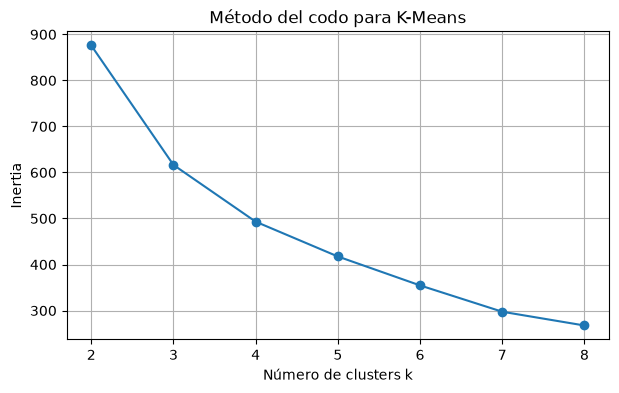

In [11]:
# metodo del codo para determinar el número óptimo de clusters
plt.figure(figsize=(7, 4))
plt.plot(kmeans_metrics["k"], kmeans_metrics["inertia"], marker="o")
plt.xlabel("Número de clusters k")
plt.ylabel("Inertia")
plt.title("Método del codo para K-Means")
plt.grid(True)
plt.show()

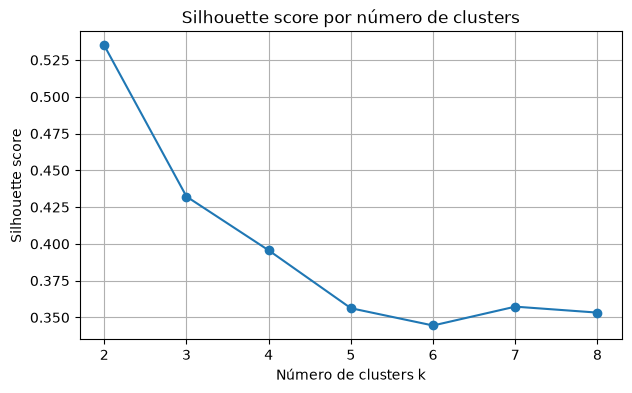

In [12]:
# grafico de silhouette score por número de clusters
plt.figure(figsize=(7, 4))
plt.plot(kmeans_metrics["k"], kmeans_metrics["silhouette_score"], marker="o")
plt.xlabel("Número de clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score por número de clusters")
plt.grid(True)
plt.show()

más alto = mejor separación promedio entre clusters
* Estadísticamente revisamos elbow y silhouette, pero mantenemos k=4 porque el negocio necesita cuatro segmentos maduros accionables: Diamante, Oro, Plata y Bronce. El segmento Nuevo se asigna aparte por regla de negocio.

In [13]:
# Entrenar K-Means 
FINAL_K = 4

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=10
)

mature_clients["cluster_id"] = kmeans.fit_predict(X_scaled_df)

mature_clients[[
    "client_id",
    "length_days",
    "recency_days",
    "frequency",
    "monetary",
    "volume",
    "score_lrfmv_0_100",
    "cluster_id",
]].head()

,client_id,length_days,recency_days,frequency,monetary,volume,score_lrfmv_0_100,cluster_id
0,CLI-0001,1356,123,1,61.68,1,28.039143,1
1,CLI-0002,1243,1,21,3861.92,3,68.476134,2
2,CLI-0003,1184,2,17,3361.16,3,64.505786,2
3,CLI-0004,1303,0,16,2336.61,3,67.178774,2
4,CLI-0005,1568,304,0,0.00,0,12.801443,1


K-Means asigna un identificador numérico a cada grupo, pero esos IDs no tienen significado comercial directo. Por eso después perfilamos cada cluster usando score, frecuencia, recencia, monto, volumen y tamaño, y recién ahí asignamos etiquetas como Diamante, Oro, Plata o Bronce.

In [14]:
# Perfilar los clusters de K-Means
cluster_profile = (
    mature_clients
    .groupby("cluster_id")
    .agg(
        n_clients=("client_id", "count"),
        avg_score=("score_lrfmv_0_100", "mean"),
        avg_length_days=("length_days", "mean"),
        avg_recency_days=("recency_days", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        avg_volume=("volume", "mean"),
        churn_rate=("is_churn_risk", "mean"),
    )
    .reset_index()
)

cluster_profile

,cluster_id,n_clients,avg_score,avg_length_days,avg_recency_days,avg_frequency,avg_monetary,avg_volume,churn_rate
0,0,34,46.660717,792.058824,28.235294,10.823529,941.069706,1.911765,0.147059
1,1,99,11.880504,1329.161616,379.666667,0.070707,4.566465,0.060606,1.000000
2,2,193,71.565578,1413.015544,5.036269,27.098446,4786.296943,3.202073,0.000000
3,3,88,49.711181,1370.727273,51.750000,9.500000,1093.305455,2.647727,0.340909


K-Means ya agrupó a los clientes maduros, pero todavía no sabemos qué significa cada grupo.

Por eso calculamos un perfil por cluster usando:

n_clients,
avg_score,
avg_length_days,
avg_recency_days,
avg_frequency,
avg_monetary,
avg_volume,
churn_rate.

* Cómo interpretar la salida real



avg_score

Nos ayuda a ordenar valor comercial general.

Alto score → posible Diamante u Oro.
Bajo score → posible Bronce.
avg_frequency

Frecuencia promedio de compra.

Alta frecuencia → cliente más recurrente.
Baja frecuencia → cliente menos activo.
avg_recency_days

Días desde la última compra.

Aquí la interpretación es inversa:

menor recency_days = mejor
mayor recency_days = peor

Un cliente que compró hace 5 días está más activo que uno que compró hace 80 días.

avg_monetary

Valor económico promedio reciente.

Alto monetary → cliente de mayor valor.
Bajo monetary → cliente de menor valor.
avg_volume

Cantidad promedio de categorías compradas.

Alto volume → compra más variedad de portafolio.
Bajo volume → compra pocas categorías.
churn_rate

Proporción de clientes en riesgo dentro del cluster.

Por ejemplo:

0.20 = 20% del cluster está en riesgo
Punto clave

Todavía no asignamos etiquetas comerciales.

In [15]:
# Ordenamos clusters desde mayor valor comercial hasta menor valor comercial
cluster_ranking = (
    cluster_profile
    .sort_values("avg_score", ascending=False)
    .reset_index(drop=True)
)

cluster_ranking

,cluster_id,n_clients,avg_score,avg_length_days,avg_recency_days,avg_frequency,avg_monetary,avg_volume,churn_rate
0,2,193,71.565578,1413.015544,5.036269,27.098446,4786.296943,3.202073,0.000000
1,3,88,49.711181,1370.727273,51.750000,9.500000,1093.305455,2.647727,0.340909
2,0,34,46.660717,792.058824,28.235294,10.823529,941.069706,1.911765,0.147059
3,1,99,11.880504,1329.161616,379.666667,0.070707,4.566465,0.060606,1.000000


La idea es:

* mayor avg_score → Diamante
* segundo mayor   → Oro
* tercero         → Plata
* menor score     → Bronce

In [16]:
commercial_labels = ["Diamante", "Oro", "Plata", "Bronce"]

cluster_label_map = {
    row["cluster_id"]: commercial_labels[i]
    for i, row in cluster_ranking.iterrows()
}

cluster_label_map

{np.float64(2.0): 'Diamante',
 np.float64(3.0): 'Oro',
 np.float64(0.0): 'Plata',
 np.float64(1.0): 'Bronce'}

In [17]:
# Aplicar etiquetas a clientes maduros
mature_clients["cluster_label"] = mature_clients["cluster_id"].map(cluster_label_map)
mature_clients["cluster_source"] = "kmeans"

mature_clients[[
    "client_id",
    "score_lrfmv_0_100",
    "cluster_id",
    "cluster_label",
    "cluster_source",
]].head()

,client_id,score_lrfmv_0_100,cluster_id,cluster_label,cluster_source
0,CLI-0001,28.039143,1,Bronce,kmeans
1,CLI-0002,68.476134,2,Diamante,kmeans
2,CLI-0003,64.505786,2,Diamante,kmeans
3,CLI-0004,67.178774,2,Diamante,kmeans
4,CLI-0005,12.801443,1,Bronce,kmeans


* Como los IDs de K-Means no tienen significado comercial directo, primero perfilamos cada cluster y luego asignamos etiquetas de negocio. En la versión simple usamos el score promedio del cluster para ordenar los segmentos: el mayor corresponde a Diamante y el menor a Bronce.

* Calculamos promedios por cluster porque K-Means solo asigna IDs numéricos sin significado comercial. Al promediar las variables LRFMV dentro de cada cluster, podemos describir el comportamiento típico del grupo y asignarle una etiqueta interpretable como Diamante, Oro, Plata o Bronce. El promedio no se usa para entrenar el modelo, sino para interpretar sus resultados.

In [18]:
# Etiquetar clientes nuevos
new_clients["cluster_id"] = -1
new_clients["cluster_label"] = "Nuevo"
new_clients["cluster_source"] = "business_rule"

new_clients[[
    "client_id",
    "length_days",
    "score_lrfmv_0_100",
    "cluster_id",
    "cluster_label",
    "cluster_source",
]].head()

,client_id,length_days,score_lrfmv_0_100,cluster_id,cluster_label,cluster_source
20,CLI-0021,129,39.286748,-1,Nuevo,business_rule
23,CLI-0024,172,39.073862,-1,Nuevo,business_rule
27,CLI-0028,165,44.243021,-1,Nuevo,business_rule
29,CLI-0030,45,30.367949,-1,Nuevo,business_rule
45,CLI-0046,28,29.921062,-1,Nuevo,business_rule


* Porque Nuevo no sale del algoritmo. Sale de una regla que definimos antes:

```es_nuevo = length_days < 180```

Entonces el origen de la etiqueta no es kmeans, sino una regla de negocio.
* El segmento Nuevo se asigna por regla de negocio porque estos clientes tienen menos de 180 días de historial transaccional. No se incluyen en K-Means para evitar compararlos injustamente con clientes maduros que sí tienen historial completo.

In [19]:
# Concatenar clientes maduros y nuevos
clients_clustered = pd.concat(
    [mature_clients, new_clients],
    axis=0,
    ignore_index=True
)

clients_clustered.shape

(498, 32)

In [20]:
# Revisar distribución de clientes por cluster
clients_clustered["cluster_label"].value_counts()

cluster_label
Diamante    193
Bronce       99
Oro          88
Nuevo        84
Plata        34
Name: count, dtype: int64

In [21]:
cluster_profile_labeled = (
    clients_clustered
    .groupby("cluster_label")
    .agg(
        n_clients=("client_id", "count"),
        avg_score=("score_lrfmv_0_100", "mean"),
        avg_length_days=("length_days", "mean"),
        avg_recency_days=("recency_days", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        avg_volume=("volume", "mean"),
        churn_rate=("is_churn_risk", "mean"),
    )
    .reset_index()
    .sort_values("avg_score", ascending=False)
)

cluster_profile_labeled

,cluster_label,n_clients,avg_score,avg_length_days,avg_recency_days,avg_frequency,avg_monetary,avg_volume,churn_rate
1,Diamante,193,71.565578,1413.015544,5.036269,27.098446,4786.296943,3.202073,0.000000
3,Oro,88,49.711181,1370.727273,51.750000,9.500000,1093.305455,2.647727,0.340909
4,Plata,34,46.660717,792.058824,28.235294,10.823529,941.069706,1.911765,0.147059
2,Nuevo,84,40.982692,89.952381,12.452381,8.583333,738.717024,1.940476,0.000000
0,Bronce,99,11.880504,1329.161616,379.666667,0.070707,4.566465,0.060606,1.000000


### Visualización de clusters K-Means

Los siguientes gráficos ayudan a revisar la separación y el perfil comercial de los clusters maduros generados por K-Means. El segmento Nuevo se muestra aparte en los gráficos agregados porque no fue asignado por el algoritmo, sino por regla de negocio.


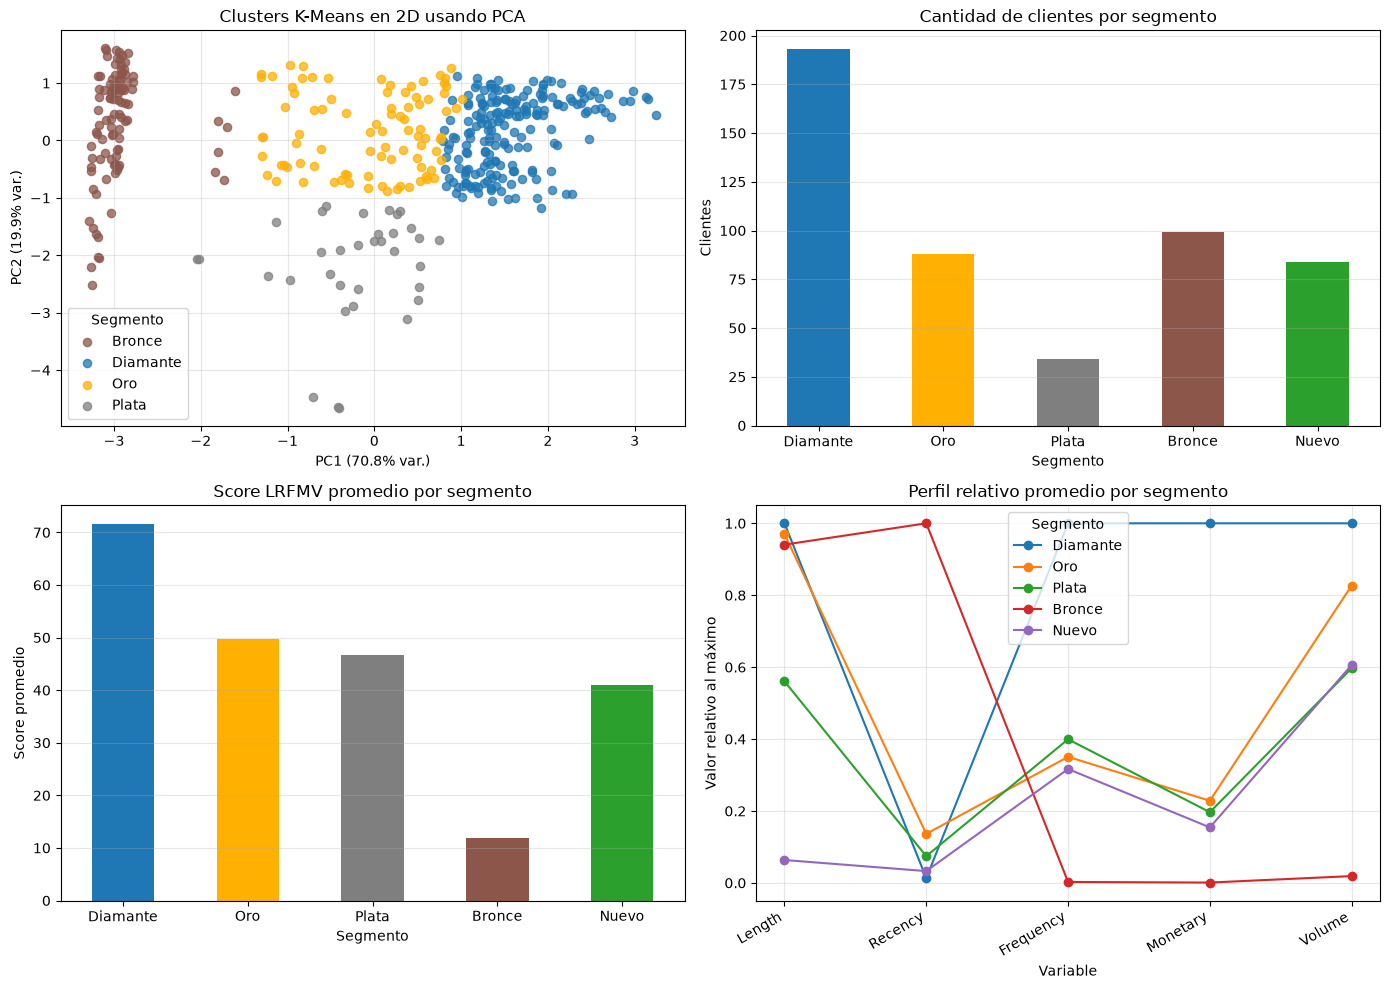

Gráfico guardado en: E:\proyecto_2026\2026-II\project_bebidas\modules\m2_lrfmv\outputs\m2\figures\kmeans_clusters_overview.png


In [22]:
# Visualizar clusters de K-Means
plot_colors = {
    "Diamante": "#1f77b4",
    "Oro": "#ffb000",
    "Plata": "#7f7f7f",
    "Bronce": "#8c564b",
    "Nuevo": "#2ca02c",
}

mature_plot = mature_clients.copy()
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled_df)

mature_plot["pca_1"] = pca_components[:, 0]
mature_plot["pca_2"] = pca_components[:, 1]
mature_plot["cluster_color"] = mature_plot["cluster_label"].map(plot_colors)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Proyección PCA de clientes maduros clusterizados por K-Means
ax = axes[0, 0]
for label, data in mature_plot.groupby("cluster_label"):
    ax.scatter(
        data["pca_1"],
        data["pca_2"],
        label=label,
        color=plot_colors.get(label, "#333333"),
        alpha=0.75,
        s=35,
    )
ax.set_title("Clusters K-Means en 2D usando PCA")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)")
ax.legend(title="Segmento")
ax.grid(True, alpha=0.3)

# 2. Distribución de clientes por segmento
ax = axes[0, 1]
cluster_counts = (
    clients_clustered["cluster_label"]
    .value_counts()
    .reindex(["Diamante", "Oro", "Plata", "Bronce", "Nuevo"])
    .dropna()
)
cluster_counts.plot(
    kind="bar",
    ax=ax,
    color=[plot_colors[label] for label in cluster_counts.index],
)
ax.set_title("Cantidad de clientes por segmento")
ax.set_xlabel("Segmento")
ax.set_ylabel("Clientes")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)

# 3. Score promedio por segmento
ax = axes[1, 0]
score_by_cluster = cluster_profile_labeled.set_index("cluster_label")["avg_score"]
score_by_cluster = score_by_cluster.reindex(["Diamante", "Oro", "Plata", "Bronce", "Nuevo"]).dropna()
score_by_cluster.plot(
    kind="bar",
    ax=ax,
    color=[plot_colors[label] for label in score_by_cluster.index],
)
ax.set_title("Score LRFMV promedio por segmento")
ax.set_xlabel("Segmento")
ax.set_ylabel("Score promedio")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)

# 4. Perfil promedio normalizado de variables clave
ax = axes[1, 1]
profile_vars = ["avg_length_days", "avg_recency_days", "avg_frequency", "avg_monetary", "avg_volume"]
profile_plot = cluster_profile_labeled.set_index("cluster_label")[profile_vars].copy()
profile_plot = profile_plot.reindex(["Diamante", "Oro", "Plata", "Bronce", "Nuevo"]).dropna(how="all")
profile_plot_norm = profile_plot / profile_plot.max()
profile_plot_norm.T.plot(kind="line", marker="o", ax=ax)
ax.set_title("Perfil relativo promedio por segmento")
ax.set_xlabel("Variable")
ax.set_ylabel("Valor relativo al máximo")
ax.set_xticks(range(len(profile_vars)))
ax.set_xticklabels(
    ["Length", "Recency", "Frequency", "Monetary", "Volume"],
    rotation=30,
    ha="right",
)
ax.grid(True, alpha=0.3)
ax.legend(title="Segmento")

plt.tight_layout()

clusters_plot_path = FIGURES_DIR / "kmeans_clusters_overview.png"
fig.savefig(clusters_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Gráfico guardado en: {clusters_plot_path}")


| Cluster  | Qué debería verse                                        |
| -------- | -------------------------------------------------------- |
| Diamante | Score alto, frecuencia alta, monetary alto, recency baja |
| Oro      | Buen score, pero menor que Diamante                      |
| Plata    | Comportamiento medio                                     |
| Bronce   | Score bajo, menor frecuencia o mayor recency             |
| Nuevo    | Menor length_days porque tiene menos de 180 días         |

* Después de asignar las etiquetas comerciales, generamos un perfil agregado por segmento para validar que los nombres tengan sentido. Esto permite comprobar que Diamante realmente representa clientes de alto valor y Bronce clientes de menor actividad o menor valor comercial.


In [23]:
SNAPSHOT_DATE = "2025-06-30"

clients_clustered["snapshot_date"] = pd.to_datetime(SNAPSHOT_DATE)

clients_clustered[["client_id", "snapshot_date"]].head()

gold_columns = [
    "client_id",
    "snapshot_date",
    "first_purchase_date",
    "last_purchase_date",
    "length_days",
    "recency_days",
    "frequency",
    "monetary",
    "volume",
    "n_transactions_total",
    "frequency_last_3_months",
    "frequency_previous_3_months",
    "delta_frequency",
    "es_nuevo",
    "churn_eligible",
    "is_churn_risk",
    "score_lrfmv_0_100",
    "cluster_id",
    "cluster_label",
    "cluster_source",
]

missing_gold_columns = [
    col for col in gold_columns
    if col not in clients_clustered.columns
]

if missing_gold_columns:
    raise ValueError(f"Faltan columnas para Gold: {missing_gold_columns}")

clients_clustered = clients_clustered[gold_columns].copy()

clients_clustered.head()

,client_id,snapshot_date,first_purchase_date,last_purchase_date,length_days,recency_days,frequency,monetary,volume,n_transactions_total,frequency_last_3_months,frequency_previous_3_months,delta_frequency,es_nuevo,churn_eligible,is_churn_risk,score_lrfmv_0_100,cluster_id,cluster_label,cluster_source
0,CLI-0001,2025-06-30,2021-10-13,2025-02-27,1356,123,1,61.68,1,137,0,1,-1,False,True,True,28.039143,1,Bronce,kmeans
1,CLI-0002,2025-06-30,2022-02-03,2025-06-29,1243,1,21,3861.92,3,148,11,10,1,False,True,False,68.476134,2,Diamante,kmeans
2,CLI-0003,2025-06-30,2022-04-03,2025-06-28,1184,2,17,3361.16,3,185,9,8,1,False,True,False,64.505786,2,Diamante,kmeans
3,CLI-0004,2025-06-30,2021-12-05,2025-06-30,1303,0,16,2336.61,3,175,7,9,-2,False,True,False,67.178774,2,Diamante,kmeans
4,CLI-0005,2025-06-30,2021-03-15,2024-08-30,1568,304,0,0.00,0,134,0,0,0,False,True,True,12.801443,1,Bronce,kmeans


In [24]:
clients_clustered.to_csv(CLIENTS_CLUSTERED_PATH, index=False)

print(f"Archivo exportado correctamente en: {CLIENTS_CLUSTERED_PATH}")
print(f"Filas exportadas: {len(clients_clustered)}")
print(f"Columnas exportadas: {len(clients_clustered.columns)}")

Archivo exportado correctamente en: E:\proyecto_2026\2026-II\project_bebidas\modules\m2_lrfmv\outputs\m2\gold\clients_clustered.csv
Filas exportadas: 498
Columnas exportadas: 20


In [25]:
cluster_profile_labeled.to_csv(CLUSTER_PROFILE_PATH, index=False)

print(f"Perfil de clusters exportado correctamente en: {CLUSTER_PROFILE_PATH}")

Perfil de clusters exportado correctamente en: E:\proyecto_2026\2026-II\project_bebidas\modules\m2_lrfmv\outputs\m2\gold\cluster_profile.csv


score_lrfmv_0_100 → prioridad comercial
is_churn_risk     → alerta de riesgo
cluster_label     → segmento comercial
cluster_source    → origen de asignación

* La capa Gold consolida la salida comercial del Módulo 2. A partir de las features LRFMV calculadas en Silver, se aplica K-Means sobre clientes maduros, se asignan etiquetas comerciales interpretables y se integran los clientes nuevos mediante regla de negocio. La tabla final queda lista para alimentar el Módulo 3 de matching preventista × cliente.

### Conclusión del notebook Gold

En este notebook se construyó la capa Gold del Módulo 2. A partir de las variables LRFMV y el score calculados en Silver, se aplicó K-Means sobre clientes maduros usando variables estandarizadas. Los clientes nuevos fueron excluidos del clustering y asignados directamente al segmento `Nuevo` mediante regla de negocio.

Los clusters generados por K-Means fueron perfilados usando score promedio, frecuencia, recencia, monetary, volume y tasa de churn. Luego se asignaron etiquetas comerciales interpretables: `Diamante`, `Oro`, `Plata` y `Bronce`.

La salida final `clients_clustered.csv` queda lista para alimentar el Módulo 3, donde se usará el `cluster_label` para asignar preventistas según compatibilidad comercial.